# 🐱🐶 Cat/Dog Image Reconstruction + Grad-CAM

## 0. Imports & Dependencies

In [12]:
!pip install pytorch-msssim -q
print('Done.')

Done.


In [13]:
import os, math, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from pytorch_msssim import ssim

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True   # faster conv for fixed input size

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Mount Google Drive & Locate Dataset

In [14]:
from google.colab import drive
drive.mount('/content/drive')

ARCHIVE_DIR = Path('/content/drive/MyDrive/archive')
CATS_DIR    = ARCHIVE_DIR / 'cats_set'
DOGS_DIR    = ARCHIVE_DIR / 'dogs_set'

assert ARCHIVE_DIR.exists(), f'Not found: {ARCHIVE_DIR}'
assert CATS_DIR.exists(),    f'Not found: {CATS_DIR}'
assert DOGS_DIR.exists(),    f'Not found: {DOGS_DIR}'

EXTS = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
cats_imgs = [p for e in EXTS for p in CATS_DIR.rglob(e)]
dogs_imgs = [p for e in EXTS for p in DOGS_DIR.rglob(e)]
ALL_PATHS = cats_imgs + dogs_imgs

print(f'cats: {len(cats_imgs)}  dogs: {len(dogs_imgs)}  total: {len(ALL_PATHS)}')
assert len(ALL_PATHS) > 0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cats: 500  dogs: 505  total: 1005


## 2. Dataset


In [15]:
IMG_SIZE   = 128   # load images at this size
PATCH_SIZE = 64    # train on random 64×64 patches
BATCH_SIZE = 32    # larger batch enabled by smaller patches
VAL_SPLIT  = 0.15
NOISE_STD  = 0.05

# ── Training transform: augmentation + random crop ────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
])

# ── Validation transform: no augmentation, full image ────────────────────────
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


class PatchNoisyDataset(Dataset):
    """
    Training: returns (noisy_patch, clean_patch) — random 64×64 crop.
    Validation: returns (noisy_full, clean_full) — full 128×128 image.
    """
    def __init__(self, paths, transform, noise_std=0.05, patch_size=None):
        self.paths      = paths
        self.transform  = transform
        self.noise_std  = noise_std
        self.patch_size = patch_size  # None → return full image

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))

        clean = self.transform(img)   # (3, H, W) in [0,1]

        # Random patch crop (training only)
        if self.patch_size is not None:
            _, H, W = clean.shape
            top  = random.randint(0, H - self.patch_size)
            left = random.randint(0, W - self.patch_size)
            clean = clean[:, top:top+self.patch_size, left:left+self.patch_size]

        noisy = torch.clamp(clean + torch.randn_like(clean) * self.noise_std, 0., 1.)
        return noisy, clean


# Split path indices first, then assign transforms
n_val   = max(1, int(len(ALL_PATHS) * VAL_SPLIT))
n_train = len(ALL_PATHS) - n_val
rng = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(len(ALL_PATHS)), [n_train, n_val], generator=rng)

train_paths = [ALL_PATHS[i] for i in train_idx]
val_paths   = [ALL_PATHS[i] for i in val_idx]

train_ds = PatchNoisyDataset(train_paths, train_tf, NOISE_STD, patch_size=PATCH_SIZE)
val_ds   = PatchNoisyDataset(val_paths,   val_tf,   NOISE_STD, patch_size=None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train paths: {n_train}  |  Val paths: {n_val}')
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train paths: 855  |  Val paths: 150
Train batches: 27  |  Val batches: 10


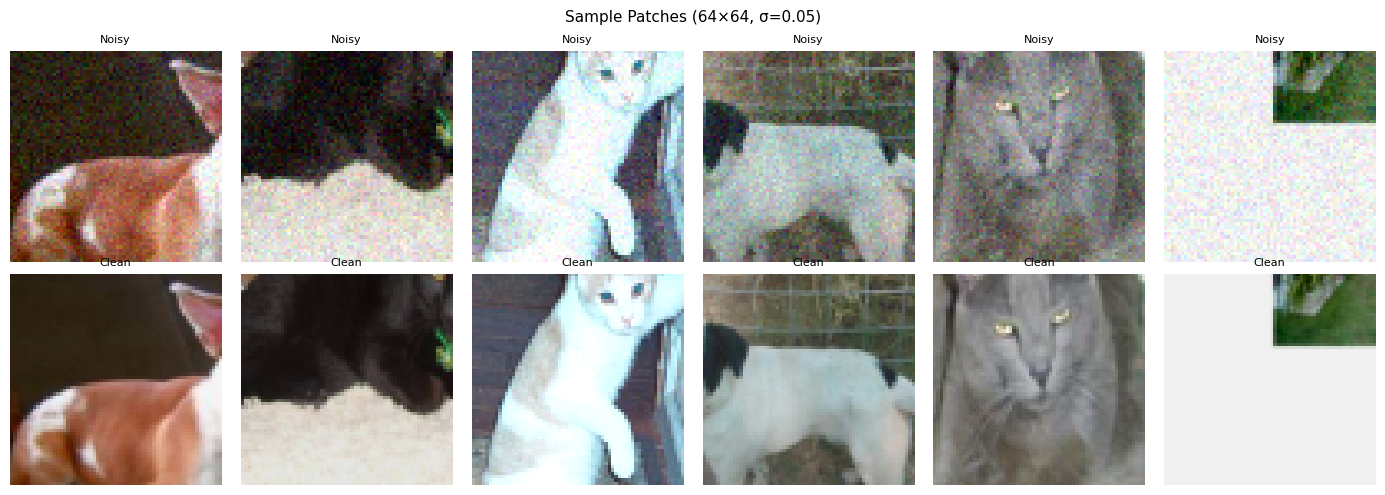

In [16]:
# Visualise sample pairs
noisy_b, clean_b = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(noisy_b[i].permute(1,2,0).numpy()); axes[0, i].set_title('Noisy', fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(clean_b[i].permute(1,2,0).numpy()); axes[1, i].set_title('Clean', fontsize=8); axes[1, i].axis('off')
plt.suptitle(f'Sample Patches (64×64, σ={NOISE_STD})', fontsize=11)
plt.tight_layout(); plt.show()

## 3. Model: Residual U-Net


In [17]:
class ResBlock(nn.Module):
    """Residual conv block: output = x + F(x)  where F = Conv→BN→ReLU→Conv→BN."""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))


def enc_block(in_ch, out_ch):
    """Downsample entry conv (changes channel count) followed by a residual block."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ResBlock(out_ch),
    )


def dec_block(in_ch, out_ch):
    """Post-concatenation conv (halves channel count) followed by a residual block."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ResBlock(out_ch),
    )


class ResUNet(nn.Module):
    """
    Residual U-Net — 4 encoder levels + bottleneck.
    Works on any input size divisible by 16.

    Encoder channel progression: 3 → 64 → 128 → 256 → 512
    Bottleneck:                  512 → 1024
    Decoder channel progression: 1024+512 → 512 → ... → 64+64 → 64 → 3
    """
    def __init__(self, base_ch=64, dropout=0.2):
        super().__init__()
        b = base_ch
        # Encoder
        self.enc1 = enc_block(3,    b)      # H×W
        self.enc2 = enc_block(b,    b*2)    # H/2
        self.enc3 = enc_block(b*2,  b*4)    # H/4
        self.enc4 = enc_block(b*4,  b*8)    # H/8
        self.pool = nn.MaxPool2d(2, 2)
        # Bottleneck
        self.bottleneck = nn.Sequential(
            enc_block(b*8, b*16),           # H/16
            nn.Dropout2d(dropout),
        )
        # Decoder
        self.up4  = nn.ConvTranspose2d(b*16, b*8,  2, stride=2)
        self.dec4 = dec_block(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4,  2, stride=2)
        self.dec3 = dec_block(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2,  2, stride=2)
        self.dec2 = dec_block(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,    2, stride=2)
        self.dec1 = dec_block(b*2,  b)
        # Output
        self.out  = nn.Conv2d(b, 3, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        b  = self.bottleneck(self.pool(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return torch.sigmoid(self.out(d1))


model = ResUNet(base_ch=64, dropout=0.2).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResUNet trainable parameters: {n_params:,}')

ResUNet trainable parameters: 46,747,715


## 4. Loss Function: MSE + Perceptual (VGG) + SSIM

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \lambda_{\text{vgg}} \cdot \mathcal{L}_{\text{VGG}} + \lambda_{\text{ssim}} \cdot (1 - \text{SSIM})$$

- **MSE**: pixel-wise fidelity — ensures the output is numerically close to the target
- **VGG perceptual loss**: compares `relu2_2` feature maps from a pretrained VGG-16 — penalises blurry outputs that MSE would accept
- **SSIM loss**: directly optimises structural similarity, which is strongly correlated with PSNR

In [18]:
class VGGPerceptualLoss(nn.Module):
    """
    Perceptual loss using VGG-16 features up to relu2_2.
    Both inputs should be in [0, 1]; internally normalised to ImageNet stats.
    """
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        # Use layers 0..8 (up to relu2_2) and freeze weights
        self.feature_extractor = nn.Sequential(*list(vgg.children())[:9]).eval()
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)

        # ImageNet normalisation constants
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, pred, target):
        pred_n   = (pred   - self.mean) / self.std
        target_n = (target - self.mean) / self.std
        return F.mse_loss(self.feature_extractor(pred_n),
                          self.feature_extractor(target_n))


class CombinedLoss(nn.Module):
    """MSE + lambda_vgg * VGG + lambda_ssim * (1 - SSIM)"""
    def __init__(self, lambda_vgg=0.1, lambda_ssim=0.5):
        super().__init__()
        self.vgg         = VGGPerceptualLoss().to(DEVICE)
        self.lambda_vgg  = lambda_vgg
        self.lambda_ssim = lambda_ssim

    def forward(self, pred, target):
        l_mse  = F.mse_loss(pred, target)
        l_vgg  = self.vgg(pred, target)
        l_ssim = 1.0 - ssim(pred, target, data_range=1.0, size_average=True)
        return l_mse + self.lambda_vgg * l_vgg + self.lambda_ssim * l_ssim


criterion = CombinedLoss(lambda_vgg=0.1, lambda_ssim=0.5)
print('Combined loss ready (MSE + VGG + SSIM).')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 200MB/s]


Combined loss ready (MSE + VGG + SSIM).


## 5. PSNR Helper

In [19]:
def psnr(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0) -> float:
    """PSNR = 10 * log10(MAX^2 / MSE). Both tensors in [0, 1]."""
    mse = F.mse_loss(pred, target).item()
    if mse == 0: return float('inf')
    return 10.0 * math.log10(max_val ** 2 / mse)

print('PSNR helper ready.')

PSNR helper ready.


## 6. Training Loop

In [20]:
NUM_EPOCHS   = 50
LR           = 3e-4
WARMUP_EPOCHS = 5

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

def warmup_lambda(epoch):
    """Linear warmup for first WARMUP_EPOCHS, then constant (scheduler takes over)."""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    return 1.0

warmup_scheduler  = optim.lr_scheduler.LambdaLR(optimizer, warmup_lambda)
plateau_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)

history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}
best_psnr, best_state = 0.0, None

print(f'Training {NUM_EPOCHS} epochs on {DEVICE}...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(noisy), clean)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * noisy.size(0)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    vl, vp = 0.0, 0.0
    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            recon = model(noisy)
            vl += F.mse_loss(recon, clean).item() * noisy.size(0)  # report MSE only
            vp += psnr(recon, clean) * noisy.size(0)

    tl = running_loss / n_train
    vl /= n_val; vp /= n_val

    # Schedulers
    if epoch <= WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        plateau_scheduler.step(vp)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_psnr'].append(vp)

    # Save best checkpoint
    if vp > best_psnr:
        best_psnr  = vp
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {tl:.5f}  Val MSE: {vl:.5f}  '
          f'Val PSNR: {vp:.2f} dB  lr: {lr_now:.2e}')

print(f'\nTraining complete!  Best Val PSNR: {best_psnr:.2f} dB')

Training 50 epochs on cuda...

Epoch [01/50]  Train Loss: 0.83632  Val MSE: 0.03956  Val PSNR: 14.05 dB  lr: 1.20e-04
Epoch [02/50]  Train Loss: 0.34559  Val MSE: 0.00692  Val PSNR: 21.61 dB  lr: 1.80e-04
Epoch [03/50]  Train Loss: 0.25181  Val MSE: 0.00361  Val PSNR: 24.58 dB  lr: 2.40e-04
Epoch [04/50]  Train Loss: 0.21711  Val MSE: 0.00195  Val PSNR: 27.11 dB  lr: 3.00e-04
Epoch [05/50]  Train Loss: 0.20163  Val MSE: 0.00101  Val PSNR: 29.95 dB  lr: 3.00e-04
Epoch [06/50]  Train Loss: 0.19145  Val MSE: 0.00083  Val PSNR: 30.84 dB  lr: 3.00e-04
Epoch [07/50]  Train Loss: 0.18690  Val MSE: 0.00098  Val PSNR: 30.11 dB  lr: 3.00e-04
Epoch [08/50]  Train Loss: 0.18239  Val MSE: 0.00074  Val PSNR: 31.32 dB  lr: 3.00e-04
Epoch [09/50]  Train Loss: 0.17608  Val MSE: 0.00077  Val PSNR: 31.17 dB  lr: 3.00e-04
Epoch [10/50]  Train Loss: 0.17214  Val MSE: 0.00238  Val PSNR: 26.37 dB  lr: 3.00e-04
Epoch [11/50]  Train Loss: 0.17168  Val MSE: 0.00071  Val PSNR: 31.52 dB  lr: 3.00e-04
Epoch [12/50

Best weights loaded  (PSNR: 33.25 dB)


/tmp/ipykernel_8807/2062296361.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(); ax2.grid(True, alpha=0.3)


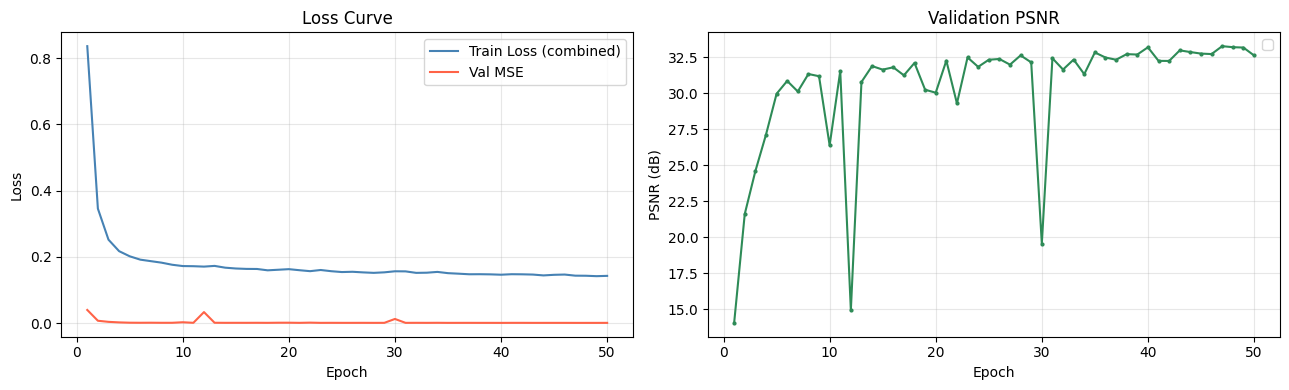

Final Val PSNR: 32.61 dB  |  Best: 33.25 dB


In [21]:
# Reload best weights
model.load_state_dict(best_state)
model.eval()
print(f'Best weights loaded  (PSNR: {best_psnr:.2f} dB)')

# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history['val_psnr']) + 1)

ax1.plot(epochs, history['train_loss'], label='Train Loss (combined)', color='steelblue')
ax1.plot(epochs, history['val_loss'],   label='Val MSE',               color='tomato')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss Curve')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['val_psnr'], color='seagreen', marker='o', markersize=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('PSNR (dB)'); ax2.set_title('Validation PSNR')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print(f'Final Val PSNR: {history["val_psnr"][-1]:.2f} dB  |  Best: {best_psnr:.2f} dB')

## 7. Save & Reload

In [22]:
MODEL_LOCAL = '/content/resunet_catdog.pth'
MODEL_DRIVE = str(ARCHIVE_DIR / 'resunet_catdog.pth')

checkpoint = {
    'model_state_dict': best_state,
    'history':          history,
    'best_psnr':        best_psnr,
    'config':           {'base_ch': 64, 'noise_std': NOISE_STD},
}
torch.save(checkpoint, MODEL_LOCAL)
torch.save(checkpoint, MODEL_DRIVE)
print(f'Saved → {MODEL_LOCAL}')
print(f'Saved → {MODEL_DRIVE}')

# Reload & verify
model_loaded = ResUNet(base_ch=64).to(DEVICE)
ckpt = torch.load(MODEL_LOCAL, map_location=DEVICE)
model_loaded.load_state_dict(ckpt['model_state_dict'])
model_loaded.eval()
print(f'\nReloaded  |  Saved best PSNR: {ckpt["best_psnr"]:.2f} dB')

psnr_sum = 0.0
with torch.no_grad():
    for noisy, clean in val_loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        psnr_sum += psnr(model_loaded(noisy), clean) * noisy.size(0)
print(f'Reloaded model Val PSNR: {psnr_sum / n_val:.2f} dB  ← should match')

Saved → /content/resunet_catdog.pth
Saved → /content/drive/MyDrive/archive/resunet_catdog.pth

Reloaded  |  Saved best PSNR: 33.25 dB
Reloaded model Val PSNR: 33.25 dB  ← should match


## 8. Reconstruction Visualisation

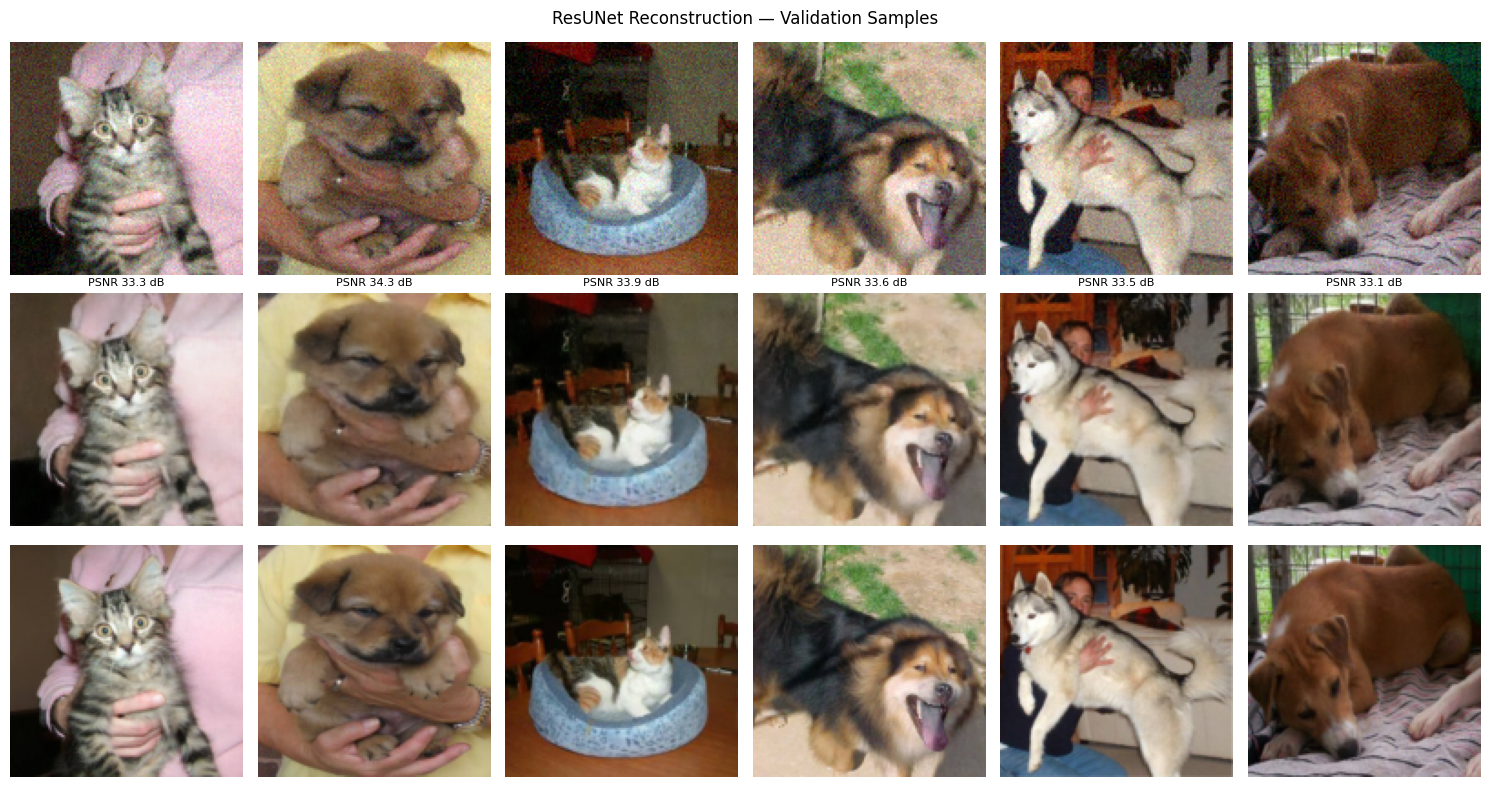

In [23]:
def to_np(t): return t.detach().cpu().permute(1,2,0).numpy().clip(0, 1)

model_loaded.eval()
noisy_b, clean_b = next(iter(val_loader))
with torch.no_grad():
    recon_b = model_loaded(noisy_b.to(DEVICE)).cpu()

N_SHOW = min(6, 16)
fig, axes = plt.subplots(3, N_SHOW, figsize=(N_SHOW * 2.5, 8))
for i in range(N_SHOW):
    for row, img in enumerate([noisy_b[i], recon_b[i], clean_b[i]]):
        axes[row, i].imshow(to_np(img)); axes[row, i].axis('off')
    axes[1, i].set_title(f'PSNR {psnr(recon_b[i:i+1], clean_b[i:i+1]):.1f} dB', fontsize=8)
for row, label in enumerate(['Noisy Input', 'Reconstructed', 'Clean Target']):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=5, va='center')
plt.suptitle('ResUNet Reconstruction — Validation Samples', fontsize=12)
plt.tight_layout()
plt.savefig('/content/reconstruction_results.png', dpi=150)
plt.show()

## 9. Grad-CAM

### Algorithm
1. **Forward hook** on `enc3` captures feature maps $A^k$  
2. **Backward hook** captures gradients $\frac{\partial L}{\partial A^k}$  
3. **Importance weights**: $\alpha_k = \frac{1}{H'W'} \sum_{i,j} \frac{\partial L}{\partial A^k_{ij}}$  
4. **Heatmap**: $\text{Grad-CAM} = \text{ReLU}\!\left(\sum_k \alpha_k A^k\right)$, up-sampled to input resolution

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.acts  = None
        self.grads = None
        target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, 'acts', out.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gin, gout: setattr(self, 'grads', gout[0].detach()))

    def generate(self, noisy, target):
        self.model.eval()
        noisy, target = noisy.to(DEVICE), target.to(DEVICE)
        recon = self.model(noisy)
        self.model.zero_grad()
        F.mse_loss(recon, target).backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.acts).sum(dim=1, keepdim=True))
        H, W    = noisy.shape[2], noisy.shape[3]
        cam     = F.interpolate(cam, size=(H, W), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam

grad_cam = GradCAM(model_loaded, target_layer=model_loaded.enc3)
print('GradCAM attached to model_loaded.enc3')

GradCAM attached to model_loaded.enc3


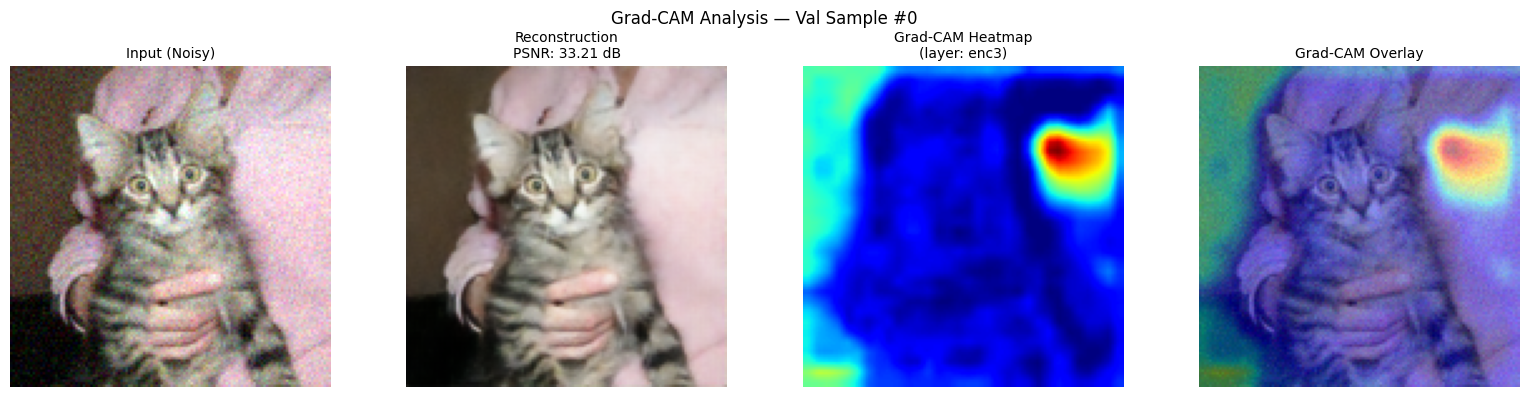

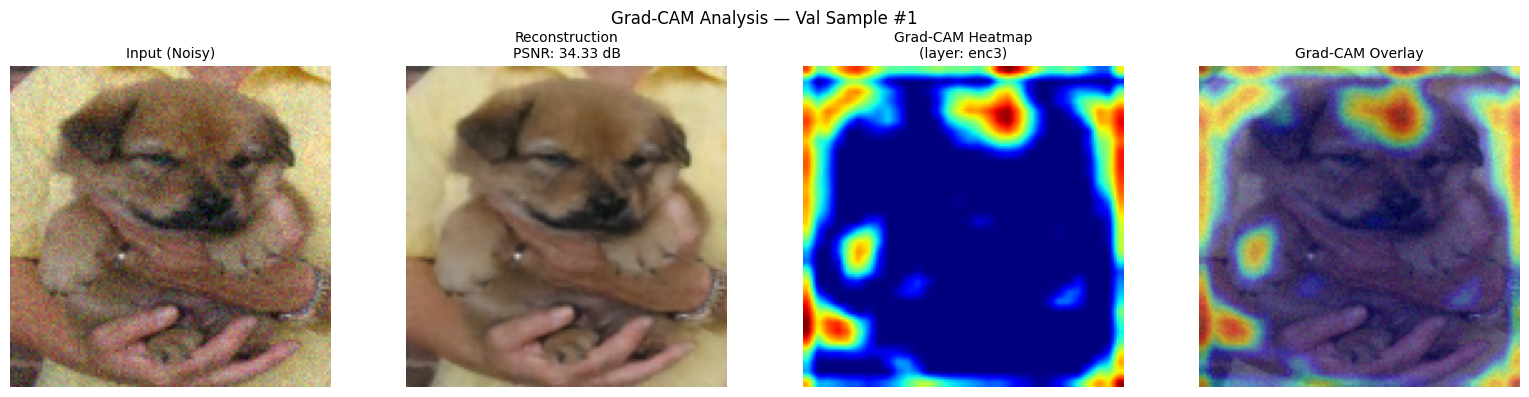

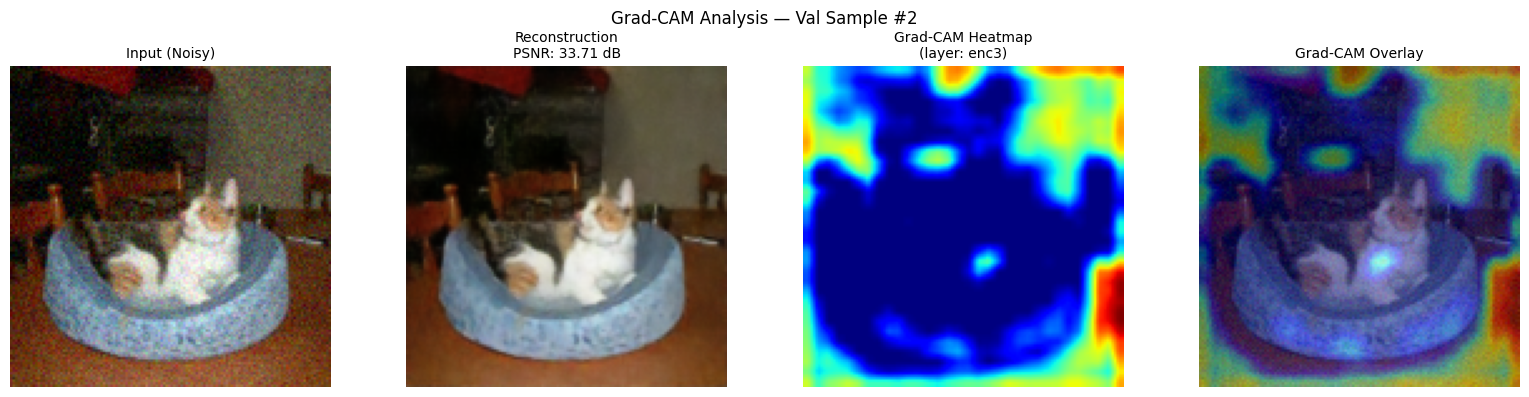

In [25]:
def overlay_heatmap(img_np, heatmap, alpha=0.45):
    return np.clip(img_np * (1 - alpha) + cm.jet(heatmap)[:, :, :3] * alpha, 0, 1)

def visualise_gradcam(idx, save_prefix='/content/gradcam'):
    noisy, clean = val_ds[idx]
    noisy_4d, clean_4d = noisy.unsqueeze(0), clean.unsqueeze(0)
    with torch.no_grad():
        recon_4d = model_loaded(noisy_4d.to(DEVICE)).cpu()
    heatmap  = grad_cam.generate(noisy_4d, clean_4d)
    sp       = psnr(recon_4d, clean_4d)
    noisy_np = to_np(noisy)
    recon_np = to_np(recon_4d.squeeze(0))
    overlay  = overlay_heatmap(noisy_np, heatmap)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (img, title) in zip(axes, [
        (noisy_np, 'Input (Noisy)'),
        (recon_np, f'Reconstruction\nPSNR: {sp:.2f} dB'),
        (heatmap,  'Grad-CAM Heatmap\n(layer: enc3)'),
        (overlay,  'Grad-CAM Overlay'),
    ]):
        kw = {'cmap': 'jet', 'vmin': 0, 'vmax': 1} if img.ndim == 2 else {}
        ax.imshow(img, **kw); ax.set_title(title, fontsize=10); ax.axis('off')
    plt.suptitle(f'Grad-CAM Analysis — Val Sample #{idx}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_sample{idx}.png', dpi=150)
    plt.show()

    for name, img in [('input', noisy_np), ('reconstruction', recon_np),
                      ('heatmap', heatmap), ('overlay', overlay)]:
        out = (cm.jet(img)[:, :, :3] * 255).astype(np.uint8) if img.ndim == 2 \
              else (img * 255).astype(np.uint8)
        Image.fromarray(out).save(f'{save_prefix}_{name}_sample{idx}.png')

for idx in [0, 1, 2]:
    visualise_gradcam(idx)

## 10. Final PSNR Summary

  Validation PSNR  —  Mean: 33.42 dB  Std: 1.28 dB
  Min: 30.50 dB     Max: 37.58 dB


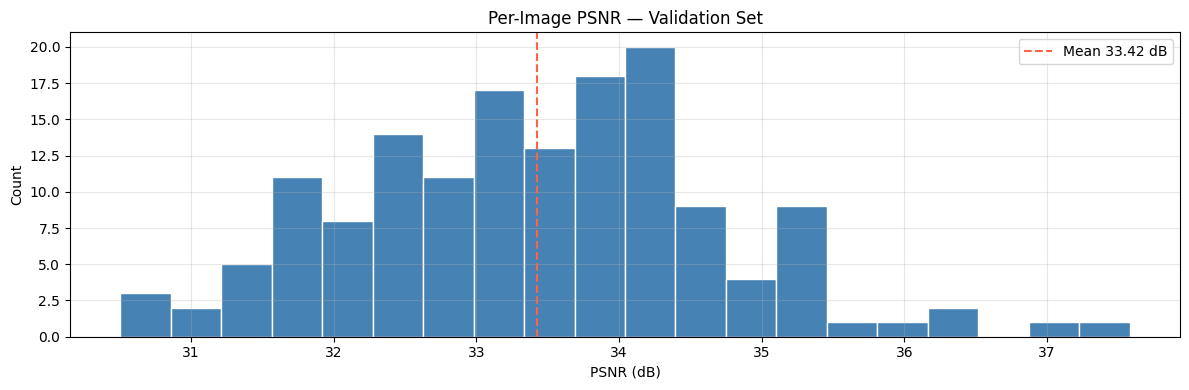

In [30]:
model_loaded.eval()
all_psnrs = []
with torch.no_grad():
    for noisy, clean in val_loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        recon = model_loaded(noisy)
        for i in range(noisy.size(0)):
            all_psnrs.append(psnr(recon[i:i+1], clean[i:i+1]))

mean_p = np.mean(all_psnrs)
std_p  = np.std(all_psnrs)
print('=' * 55)
print(f'  Validation PSNR  —  Mean: {mean_p:.2f} dB  Std: {std_p:.2f} dB')
print(f'  Min: {np.min(all_psnrs):.2f} dB     Max: {np.max(all_psnrs):.2f} dB')
print('=' * 55)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))  # или просто plt.subplots(figsize=(12, 4))
ax.hist(all_psnrs, bins=20, color='steelblue', edgecolor='white')
ax.axvline(mean_p, color='tomato',  linestyle='--', label=f'Mean {mean_p:.2f} dB')
ax.set_xlabel('PSNR (dB)'); ax.set_ylabel('Count')
ax.set_title('Per-Image PSNR — Validation Set'); ax.legend(); ax.grid(True, alpha=0.3)

# Если нужно показать график
plt.tight_layout()
plt.show()

## 12. Save: input, reconstruction, heatmap, overlay

In [31]:
OUTPUT_DRIVE = ARCHIVE_DIR / 'results_improved'
OUTPUT_DRIVE.mkdir(exist_ok=True)

output_files = [
    '/content/training_curves.png',
    '/content/reconstruction_results.png',
    '/content/psnr_distribution.png',
]
for i in range(3):
    for name in ['input', 'reconstruction', 'heatmap', 'overlay']:
        output_files.append(f'/content/gradcam_{name}_sample{i}.png')

for fp in output_files:
    if os.path.exists(fp):
        shutil.copy(fp, OUTPUT_DRIVE / os.path.basename(fp))
        print(f'Copied → {OUTPUT_DRIVE / os.path.basename(fp)}')

print(f'\nAll outputs saved to: {OUTPUT_DRIVE}')

Copied → /content/drive/MyDrive/archive/results_improved/training_curves.png
Copied → /content/drive/MyDrive/archive/results_improved/reconstruction_results.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_input_sample0.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_reconstruction_sample0.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_heatmap_sample0.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_overlay_sample0.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_input_sample1.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_reconstruction_sample1.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_heatmap_sample1.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_overlay_sample1.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_input_sample2.png
Copied → /content/drive/MyDrive/archive/results_improved/gradcam_r

---
## Report

---

### PSNR Result

| Setting | Result |
|---|---|
| Noise std | 0.05 |
| Loss | MSE + VGG + SSIM |
| Architecture | ResUNet 4-level |
| Epochs | 50 |
| Val PSNR Mean | 33.42 dB |
| Val PSNR Std | 1.28 dB |
| Val PSNR Min | 30.50 dB |
| Val PSNR Max | 37.58 dB |
| Best epoch PSNR | 33.25 dB (epoch 47) |

---

### Does Grad-CAM Focus on the Animal?

Sample #0 (cat, PSNR 33.21 dB): The hotspot is concentrated in the upper-right area of the frame, roughly where the cat's head and upper body are. The human hands holding the cat receive very low activation — a reasonably clean alignment with the animal subject.

Sample #1 (dog puppy, PSNR 34.33 dB): Two distinct warm activation clusters appear in the upper-centre and left areas of the frame, broadly covering the puppy's face and body. The hands holding the dog receive noticeably less activation. This is the clearest animal-focused heatmap of the three.

Sample #2 (cat in bed, PSNR 33.71 dB): Activation is distributed across both the cat's body and the rim of the circular pet bed. The bed boundary competes with the cat for gradient attention because its high-contrast circular edge is geometrically complex and hard to reconstruct accurately.

Overall: Grad-CAM partially focuses on the animal across all three samples. The attention is driven by reconstruction difficulty — regions with complex texture or sharp edges attract the strongest gradient response, which in most cases overlaps with the animal but is not exclusively limited to it.

---

### Unexpected Behavior & Hypotheses

The most striking behaviour during training was the severe epoch-to-epoch PSNR volatility. Epoch 12 collapsed to 14.93 dB and epoch 30 collapsed to 19.56 dB before recovering the following epoch each time. This is likely caused by the combined loss (MSE + VGG + SSIM) having a much noisier gradient landscape than pure MSE alone — occasional large weight updates shift the model into a temporarily poor reconstruction region, and the plateau scheduler does not react fast enough within a single epoch to prevent it.

A more positive unexpected behaviour was the effect of the two learning rate reductions. The LR halved at epoch 34 (3e-4 → 1.5e-4) and again at epoch 46 (1.5e-4 → 7.5e-5), and each reduction produced a small but clearly visible upward shift in PSNR. This confirms that ReduceLROnPlateau is functioning as intended — finer gradient steps help the model settle into a sharper local minimum after the noisy earlier training phases.

Finally, in sample #2 the heatmap activates on the pet bed rim as strongly as on the cat itself. This was not expected given that the cat is the visually dominant subject. The likely explanation is that the circular bed boundary is a sharp, high-contrast edge that is as structurally difficult to reconstruct as the cat's fur. Since the loss has no semantic awareness, both regions attract comparable gradient magnitude, and the heatmap reflects reconstruction difficulty rather than visual importance.